In [38]:
#Importing the libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, levene, shapiro

In [39]:
#loading the dataset
df = pd.read_csv("merged_sleep_lifestyle_NEW_2.csv")

In [40]:
print(df.columns)

Index(['Age', 'Weight (kg)_mean', 'Height (m)_mean', 'Calories_Burned_mean',
       'Water_Intake (liters)_mean', 'Workout_Frequency (days/week)_mean',
       'BMI_mean', 'Physical exercise_mean', 'Carbs_mean', 'Proteins_mean',
       'Fats_mean', 'Calories_mean', 'sugar_g_mean', 'sodium_mg_mean',
       'cholesterol_mg_mean', 'Burns Calories (per 30 min)_mean',
       'Sleep Duration_mean', 'Quality of Sleep_mean',
       'Physical Activity Level_mean', 'Stress Level_mean', 'Heart Rate_mean',
       'Daily Steps_mean', 'Gender_Male_pct', 'Gender_Female_pct',
       'meal_type_Snack_pct', 'meal_type_Lunch_pct', 'meal_type_Breakfast_pct',
       'meal_type_Dinner_pct', 'diet_type_Low-Carb_pct', 'diet_type_Vegan_pct',
       'diet_type_Keto_pct', 'diet_type_Balanced_pct', 'diet_type_Paleo_pct',
       'diet_type_Vegetarian_pct', 'cooking_method_Baked_pct',
       'cooking_method_Boiled_pct', 'cooking_method_Raw_pct',
       'cooking_method_Steamed_pct', 'cooking_method_Fried_pct',
      

Null Hypothesis (H₀):
There is no difference in the mean Stress Level among the three workout groups (Low, Medium, High).
→ Workout frequency does NOT affect stress.

Alternative Hypothesis (H₁):
At least one workout group has a different mean Stress Level.
→ Workout frequency does affect stress.

Test justification and selection:

A One-Way ANOVA was used because we wanted to compare the mean stress levels across three independent workout groups (Low, Medium, High). ANOVA is the correct test when the dependent variable is continuous and the independent variable has three or more categories.ANOVA is the appropriate and standard method for this comparison.

In [41]:
# Select the two columns for ANOVA
work_col = "Workout_Frequency (days/week)_mean"
stress_col = "Stress Level_mean"

In [42]:
# Function to divide workout frequency into 3 equal groups:
# Low, Medium, High (based on percentiles)
def make_3_groups(series):
    try:
        return pd.qcut(series, 3, labels=["Low","Medium","High"])
    except:
        p33, p66 = np.percentile(series.dropna(), [33,66])
        return pd.cut(series, bins=[-np.inf, p33, p66, np.inf], labels=["Low","Medium","High"])
        

In [43]:
## Create workout intensity groups
df['workout_group'] = make_3_groups(df[work_col])

In [44]:
#Keep only rows where both stress level and workout group are available
df_anova = df[[stress_col, 'workout_group']].dropna()

In [45]:
#Show how many samples are in each group (important for ANOVA)
print("Group sizes:")
print(df_anova['workout_group'].value_counts())

Group sizes:
workout_group
Low       15
Medium    14
High      14
Name: count, dtype: int64


In [46]:
#Check if any group has fewer than 2 values (ANOVA requires this minimum)
counts = df_anova['workout_group'].value_counts()
if (counts < 2).any():
    raise ValueError("One or more groups have fewer than 2 observations. Cannot run ANOVA reliably.")

In [47]:
#Create separate vectors for Low, Medium, High groups
groups = [df_anova[df_anova['workout_group']==g][stress_col] for g in ["Low","Medium","High"]]

In [48]:
#Assumption 1: Homogeneity of Variances (Levene's test)
#Levene’s test checks whether the variances of the groups are equal.
levene_stat, levene_p = levene(*groups)
print(f"\nLevene's test: W = {levene_stat:.4f}, p = {levene_p:.6f}")


Levene's test: W = 0.0102, p = 0.989840


Since p > 0.05, we fail to reject the null hypothesis of equal variances.
The variances across the Low, Medium, and High workout groups are equal.
Therefore, the homogeneity of variances assumption is satisfied, meaning ANOVA can be appropriately used.

In [49]:
#Assumption 2: Normality (Shapiro-Wilk test for each group)
#The Shapiro–Wilk test checks whether each group’s values are approximately normally distributed.
print("\nShapiro-Wilk per group (W, p, n):")
for g, grp in zip(["Low","Medium","High"], groups):
    if len(grp) >= 3:
        w, p = shapiro(grp)
        print(f"{g}: W={w:.4f}, p={p:.6f}, n={len(grp)}")
    else:
        print(f"{g}: Too few observations for Shapiro (n={len(grp)})")


Shapiro-Wilk per group (W, p, n):
Low: W=0.8935, p=0.075699, n=15
Medium: W=0.8772, p=0.053091, n=14
High: W=0.9432, p=0.461438, n=14


Since p > 0.05, we fail to reject the null hypothesis of equal variances.
The variances across the Low, Medium, and High workout groups are equal.
Therefore, the homogeneity of variances assumption is satisfied, meaning ANOVA can be appropriately used.

In [50]:
#One-way ANOVA test
f_stat, p_val = f_oneway(*groups)
print(f"\nOne-way ANOVA: F = {f_stat:.4f}, p = {p_val:.6f}")


One-way ANOVA: F = 0.7455, p = 0.480976


The ANOVA test shows no significant difference in stress levels among the Low, Medium, and High workout groups (p = 0.48)

We fail to reject the null hypothesis (H₀).

Based on the ANOVA analysis (F = 0.7455, p = 0.480976), workout frequency does not have a statistically significant effect on stress levels in this dataset. The stress level means across the three groups (Low, Medium, High) are similar, indicating that differences in workout frequency do not lead to notable changes in stress.

/var/folders/hm/7xxfsvg12s95bg01kxblr6200000gn/T/ipykernel_39850/3585478112.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_means = df_anova.groupby('workout_group')['Stress Level_mean'].mean()


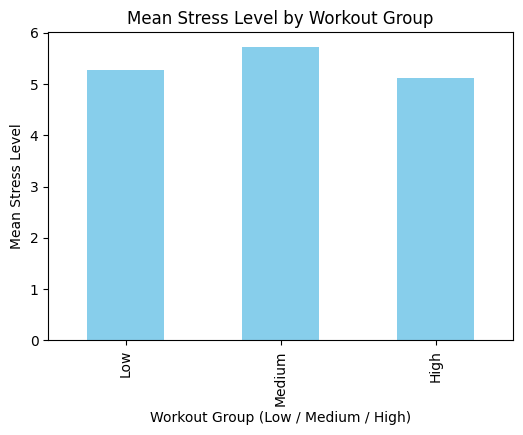

In [56]:
## Calculate the mean stress level for each workout group
group_means = df_anova.groupby('workout_group')['Stress Level_mean'].mean()

## Create a bar plot of the group means
plt.figure(figsize=(6,4))
group_means.plot(kind='bar', color='skyblue')

## Add title and axis labels
plt.title("Mean Stress Level by Workout Group")
plt.xlabel("Workout Group (Low / Medium / High)")
plt.ylabel("Mean Stress Level")

## Display the plot
plt.show()


The bar chart shows that the average stress levels across the Low, Medium, and High workout groups are nearly the same, supporting the ANOVA result that workout frequency does not significantly affect stress.